In [2]:
%matplotlib widget

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
spectrum_1 = pd.read_csv("Spectrum2s_1_noreg_gas_exp.csv")
spectrum_1 = spectrum_1.set_index('Name')
spectrum_2 = pd.read_csv("Spectrum2s_2_noreg_gas_exp.csv")
spectrum_2 = spectrum_2.set_index('Name')
spectrum_3 = pd.read_csv("Spectrum2s_3_noreg_gas_exp.csv")
spectrum_3 = spectrum_3.set_index('Name')
#spectrum_4 = pd.read_csv("Spectrum1s_4_noreg_gas_exp.csv")
#spectrum_4 = spectrum_4.set_index('Name')
#spectrum_5 = pd.read_csv("Spectrum1s_5_noreg_gas_exp.csv")
#spectrum_5 = spectrum_5.set_index('Name')

SNR_HA = pd.read_csv("SNR_HA_2s.csv")
SNR_HB = pd.read_csv("SNR_HB_2s.csv") 
SNR_NII_2 = pd.read_csv("SNR_NII_2_2s.csv") 
SNR_OIII_2 = pd.read_csv("SNR_OIII_2_2s.csv") 
SNR_SII_1 = pd.read_csv("SNR_SII_1_2s.csv") 
SNR_OI = pd.read_csv("SNR_OI_2s.csv")
SNR_HeII = pd.read_csv("SNR_HeII_2s.csv")

In [5]:
def Ke_OI(x):
    return 0.73/(x + 0.59) + 1.33

def error_ratio(err_1, err_2, flux_1, flux_2):
    e_1 = err_1/(flux_1*np.log(10))
    e_2 = err_2/(flux_2*np.log(10))
    print(np.sqrt((e_1)**2+(e_2)**2))
    return np.sqrt((e_1)**2+(e_2)**2)

def ratio(spectrum):
    OIII_HB = spectrum.loc['[OIII]5007', 'Flux']/spectrum.loc['Hbeta', 'Flux']
    OI_HA = spectrum.loc['[OI]6300', 'Flux']/spectrum.loc['Halpha', 'Flux']
    err_OIII_HB = error_ratio(spectrum.loc['[OIII]5007', 'Error_flux'], spectrum.loc['Hbeta', 'Error_flux'], spectrum.loc['[OIII]5007', 'Flux'], spectrum.loc['Hbeta', 'Flux'])
    err_OI_HA = error_ratio(spectrum.loc['[OI]6300', 'Error_flux'], spectrum.loc['Halpha', 'Error_flux'], spectrum.loc['[OI]6300', 'Flux'], spectrum.loc['Halpha', 'Flux']) 
    return OIII_HB, OI_HA, err_OIII_HB, err_OI_HA

def evaluation_SNR(SNR_HA, SNR_HB, SNR_NII, SNR_SII, SNR_OIII):
    if (SNR_HB < 0) and (SNR_OIII >= 3) and (SNR_HA >= 3) and (SNR_NII >= 3) and (SNR_SII >= 3):
        print('HB<0 but OIII>3')
        return True 
    elif (SNR_HB >= 3) and (SNR_OIII >= 3) and (SNR_HA >= 3) and (SNR_NII >= 3) and (SNR_SII >= 3):
        print('All ok')
        return True 
    else: 
        print('False')
        return False 

In [6]:
for i in range(3):
    print(i+1)
    evaluation_SNR(SNR_HA['SNR'][i], SNR_HB['SNR'][i], SNR_NII_2['SNR'][i], SNR_SII_1['SNR'][i], SNR_OIII_2['SNR'][i])
for i in range(3):
    if SNR_OI['SNR'][i] >= 3:
        print(i+1, 'SNR(OI) ok')
    else:
        print(i+1, 'SNR(OI) X')

for i in range(3):
    if SNR_HeII['SNR'][i] >= 3:
        print(i+1, 'SNR(HeII) ok')
    else:
        print(i+1, 'SNR(HeII) X')

1
All ok
2
All ok
3
All ok
1 SNR(OI) ok
2 SNR(OI) ok
3 SNR(OI) ok
1 SNR(HeII) X
2 SNR(HeII) X
3 SNR(HeII) X


0.03785128726180989
0.040313208420117395
0.031627797058253
0.023029106502172058
0.055322718464554436
0.04448903794815855


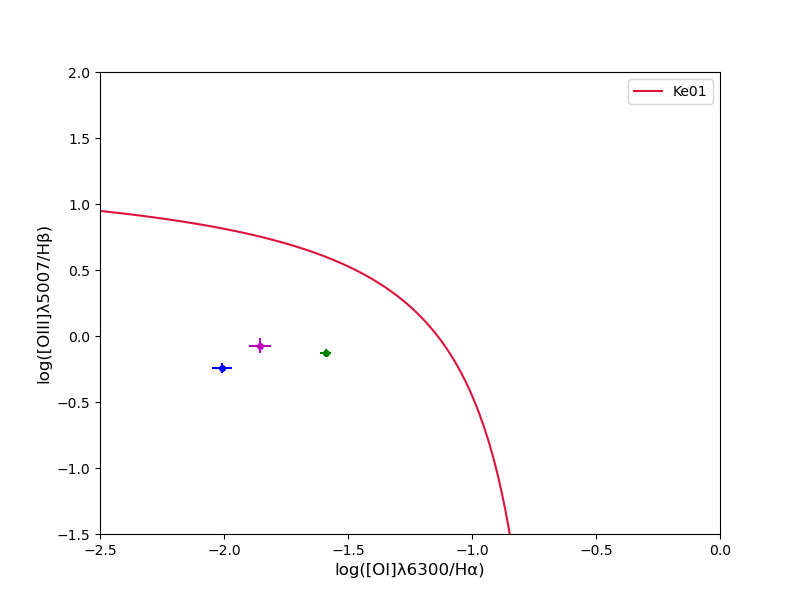

In [6]:
plt.figure(figsize=(8,6))

OIII_HB_1, OI_HA_1, err_OIII_HB_1, err_OI_HA_1 = ratio(spectrum_1)
OIII_HB_2, OI_HA_2, err_OIII_HB_2, err_OI_HA_2 = ratio(spectrum_2)
OIII_HB_3, OI_HA_3, err_OIII_HB_3, err_OI_HA_3 = ratio(spectrum_3)
#OIII_HB_4, OI_HA_4, err_OIII_HB_4, err_OI_HA_4 = ratio(spectrum_4)
#OIII_HB_5, OI_HA_5, err_OIII_HB_5, err_OI_HA_5= ratio(spectrum_5)

plt.errorbar(x = np.log10(OI_HA_1), y = np.log10(OIII_HB_1), xerr = err_OI_HA_1, yerr = err_OIII_HB_1, color = 'blue', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(OI_HA_2), y =np.log10(OIII_HB_2), xerr = err_OI_HA_2, yerr = err_OIII_HB_2,  color = 'green', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(OI_HA_3), y = np.log10(OIII_HB_3), xerr = err_OI_HA_3, yerr = err_OIII_HB_3, color = 'm', markersize = 4, marker = 'o')
#plt.errorbar(x = np.log10(OI_HA_4), y = np.log10(OIII_HB_4), xerr = err_OI_HA_4, yerr = err_OIII_HB_4, color = 'orange', markersize = 4, marker = 'o')
#plt.errorbar(x = np.log10(OI_HA_5), y =np.log10(OIII_HB_5), xerr = err_OI_HA_5, yerr = err_OIII_HB_5,  color = 'chocolate', markersize = 4, marker = 'o')

x = np.linspace(-2.5, -0.7, num=200)
x1 = np.linspace(-0.31, 1, num=200)

plt.plot(x, Ke_OI(x), label = 'Ke01', color = 'crimson')
#plt.plot(x1, Ke06(x1), label = 'Ke06')

plt.xlim(-2.5, 0)
plt.ylim(-1.5, 2)
plt.xlabel('log([OI]λ6300/Hα)', fontsize=12)
plt.ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
plt.legend()
plt.savefig('BPT_OI_2s', bbox_inches='tight')